# EDA — Comunas y barrios de Cali (`mc_barrios`)

Análisis exploratorio del shapefile oficial de **manzanas censales / barrios** de Santiago de Cali.

| Fuente | `data/mc_barrios/mc_barrios.shp` (+ `.dbf`, `.prj`, `.shx`) |
|--------|-------------------------------------------------------------|
| CRS original | EPSG:6249 (MAGNA-SIRGAS / Cali-Valle 2009) |
| Registros | 339 polígonos (barrios) en 22 comunas |

**Columnas:** `id_barrio`, `barrio`, `comuna`, `shape_leng`, `shape_area`, `geometry`

In [2]:
# @title Dependencias
%pip install -q geopandas pyogrio matplotlib seaborn pandas

Note: you may need to restart the kernel to use updated packages.


In [3]:
# @title Rutas y carga del shapefile
from pathlib import Path
import json
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=0.95)

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "data" / "mc_barrios").is_dir():
    REPO_ROOT = Path.cwd().parent
assert (REPO_ROOT / "data" / "mc_barrios" / "mc_barrios.shp").is_file(), (
    "No se encontró data/mc_barrios/mc_barrios.shp — ejecuta desde la raíz del repo"
)

SHP_PATH = REPO_ROOT / "data" / "mc_barrios" / "mc_barrios.shp"
OUT_DIR = REPO_ROOT / "data" / "mc_barrios" / "eda"
OUT_DIR.mkdir(parents=True, exist_ok=True)

gdf = gpd.read_file(SHP_PATH)
gdf_wgs = gdf.to_crs(4326)

print(f"Registros: {len(gdf)} barrios")
print(f"CRS: {gdf.crs}")
print(f"Comunas: {gdf['comuna'].nunique()}")
print(f"Salida EDA: {OUT_DIR}")

Registros: 339 barrios
CRS: EPSG:6249
Comunas: 22
Salida EDA: c:\Users\nicor\universidad\analitica\proyectos\proyecto 3.1\data\mc_barrios\eda


## 1. Vista general del dataset

In [4]:
# @title Esquema, tipos y primeras filas
print("=== Columnas ===")
print(gdf.dtypes)
print("\n=== Muestra (atributos) ===")
display(gdf.drop(columns="geometry").head(10))

print("\n=== Valores nulos ===")
print(gdf.drop(columns="geometry").isnull().sum())

print("\n=== Geometría ===")
print(f"Válidas: {gdf.geometry.is_valid.all()}")
print(f"Vacías: {int(gdf.geometry.is_empty.sum())}")
print(f"Tipos: {gdf.geom_type.value_counts().to_dict()}")

bounds = gdf_wgs.total_bounds
print(f"\nExtensión WGS84: lon [{bounds[0]:.4f}, {bounds[2]:.4f}] | lat [{bounds[1]:.4f}, {bounds[3]:.4f}]")

=== Columnas ===
id_barrio       object
barrio          object
comuna          object
shape_leng     float64
shape_area     float64
geometry      geometry
dtype: object

=== Muestra (atributos) ===


,id_barrio,barrio,comuna,shape_leng,shape_area
0,0610,Ciudadela Floralia,06,4062.458,768879.612
1,0216,Menga,02,3209.059,510671.138
2,0603,Paso del Comercio,06,3573.425,395204.900
3,0608,Los Guaduales,06,2572.876,364831.767
4,0298,Senderos de La Flora,02,2543.263,383903.117
5,0295,Urbanización La Flora,02,3508.308,764277.961
6,0296,Altos de Menga,02,3582.164,178496.115
7,0213,La Campiña,02,1910.456,138994.565
8,0697,Urbanización Calimio,06,2564.909,248885.413
9,0696,San Luis II,06,2814.509,390316.799



=== Valores nulos ===
id_barrio     0
barrio        0
comuna        0
shape_leng    0
shape_area    0
dtype: int64

=== Geometría ===
Válidas: True
Vacías: 0
Tipos: {'Polygon': 339}

Extensión WGS84: lon [-76.5908, -76.4613] | lat [3.3318, 3.5019]


In [5]:
# @title Estadísticas descriptivas (área y perímetro)
gdf["area_km2"] = gdf["shape_area"] / 1e6
gdf["perim_km"] = gdf["shape_leng"] / 1e3

stats = gdf[["shape_area", "shape_leng", "area_km2", "perim_km"]].describe().round(4)
display(stats)
stats.to_csv(OUT_DIR / "estadisticas_area_perimetro.csv")
print("Guardado:", OUT_DIR / "estadisticas_area_perimetro.csv")

,shape_area,shape_leng,area_km2,perim_km
count,3.390000e+02,339.0000,339.0000,339.0000
mean,3.540544e+05,2586.2824,0.3541,2.5863
std,5.028702e+05,1285.7970,0.5029,1.2858
min,2.522299e+04,706.3140,0.0252,0.7063
25%,1.335000e+05,1711.2200,0.1335,1.7112
50%,2.521958e+05,2371.6200,0.2522,2.3716
75%,4.382161e+05,3131.2450,0.4382,3.1312
max,7.968927e+06,12219.0750,7.9689,12.2191


Guardado: c:\Users\nicor\universidad\analitica\proyectos\proyecto 3.1\data\mc_barrios\eda\estadisticas_area_perimetro.csv


## 2. Comunas — cuántos barrios y área por comuna

In [6]:
# @title Tabla por comuna
por_comuna = (
    gdf.groupby("comuna", as_index=False)
    .agg(
        n_barrios=("barrio", "count"),
        area_total_km2=("area_km2", "sum"),
        area_media_km2=("area_km2", "mean"),
        area_max_km2=("area_km2", "max"),
    )
    .sort_values("comuna", key=lambda s: s.astype(int))
)
por_comuna["pct_barrios"] = (100.0 * por_comuna["n_barrios"] / len(gdf)).round(1)
por_comuna["pct_area"] = (100.0 * por_comuna["area_total_km2"] / gdf["area_km2"].sum()).round(1)

display(por_comuna)
por_comuna.to_csv(OUT_DIR / "resumen_por_comuna.csv", index=False)
print("Guardado:", OUT_DIR / "resumen_por_comuna.csv")

,comuna,n_barrios,area_total_km2,area_media_km2,area_max_km2,pct_barrios,pct_area
0,01,4,4.052800,1.013200,1.455186,1.2,3.4
1,02,25,10.863077,0.434523,0.958241,7.4,9.1
2,03,15,3.704255,0.246950,0.858315,4.4,3.1
3,04,22,4.522666,0.205576,0.503484,6.5,3.8
4,05,12,4.199642,0.349970,0.786440,3.5,3.5
5,06,17,4.630243,0.272367,0.789520,5.0,3.9
6,07,13,5.213197,0.401015,1.694379,3.8,4.3
7,08,18,5.270329,0.292796,0.603004,5.3,4.4
8,09,10,2.901208,0.290121,0.496191,2.9,2.4
9,10,18,4.297756,0.238764,0.590528,5.3,3.6


Guardado: c:\Users\nicor\universidad\analitica\proyectos\proyecto 3.1\data\mc_barrios\eda\resumen_por_comuna.csv


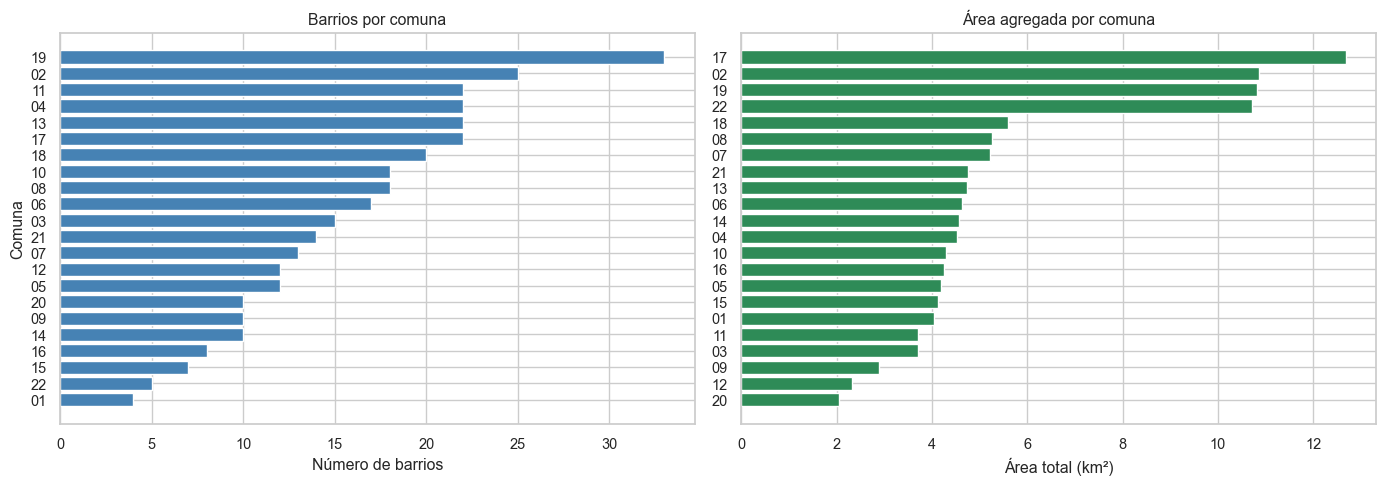

In [7]:
# @title Gráficos — barrios y área por comuna
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

orden = por_comuna.sort_values("n_barrios", ascending=True)
axes[0].barh(orden["comuna"].astype(str), orden["n_barrios"], color="steelblue")
axes[0].set_xlabel("Número de barrios")
axes[0].set_ylabel("Comuna")
axes[0].set_title("Barrios por comuna")

orden_a = por_comuna.sort_values("area_total_km2", ascending=True)
axes[1].barh(orden_a["comuna"].astype(str), orden_a["area_total_km2"], color="seagreen")
axes[1].set_xlabel("Área total (km²)")
axes[1].set_title("Área agregada por comuna")

plt.tight_layout()
plt.savefig(OUT_DIR / "01_barrios_area_por_comuna.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Barrios — distribución de tamaños y outliers

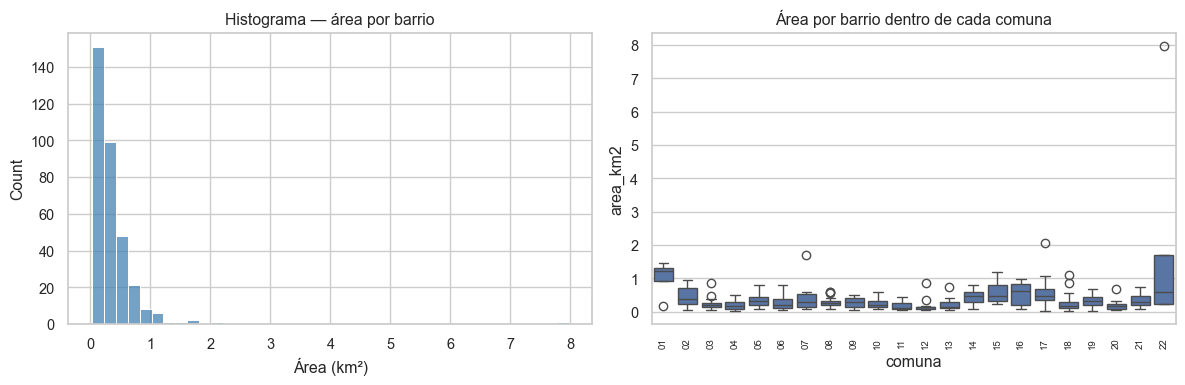

=== 10 barrios más grandes (km²) ===


,id_barrio,barrio,comuna,area_km2
323,2296,Parcelaciones Pance,22,7.968927
313,1775,Lili,17,2.067701
321,2201,Urbanización Ciudad Jardín,22,1.694399
65,0711,Base Aérea,07,1.694379
88,0101,Terron Colorado,01,1.455186
67,0199,Aguacatal,01,1.273634
276,1599,El Morichal,15,1.195561
79,0102,Vista Hermosa,01,1.149440
310,1816,Cuarteles de Nápoles,18,1.100564
306,1705,Ciudad Universitaria,17,1.071629


=== 10 barrios más pequeños (km²) ===


,id_barrio,barrio,comuna,area_km2
318,1701,La Playa,17,0.025223
299,1812,Colinas del Sur,18,0.028104
44,0414,Marco Fidel Suárez,04,0.031795
117,1982,Santa Bárbara,19,0.033767
64,0407,Fátima,04,0.034397
167,1212,Bello Horizonte,12,0.040280
234,2001,El Cortijo,20,0.045644
225,1102,Maracaibo,11,0.046651
337,0604,Los Alcazares Primera Etapa,06,0.049129
18,1104,La Esperanza,11,0.051044


In [8]:
# @title Distribución de área por barrio
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(gdf["area_km2"], bins=40, ax=axes[0], color="steelblue")
axes[0].set_xlabel("Área (km²)")
axes[0].set_title("Histograma — área por barrio")

sns.boxplot(data=gdf, x="comuna", y="area_km2", ax=axes[1], order=sorted(gdf["comuna"].unique(), key=int))
axes[1].tick_params(axis="x", rotation=90, labelsize=7)
axes[1].set_title("Área por barrio dentro de cada comuna")

plt.tight_layout()
plt.savefig(OUT_DIR / "02_distribucion_area_barrios.png", dpi=150, bbox_inches="tight")
plt.show()

top_grandes = gdf.nlargest(10, "area_km2")[["id_barrio", "barrio", "comuna", "area_km2"]]
top_chicos = gdf.nsmallest(10, "area_km2")[["id_barrio", "barrio", "comuna", "area_km2"]]
print("=== 10 barrios más grandes (km²) ===")
display(top_grandes)
print("=== 10 barrios más pequeños (km²) ===")
display(top_chicos)

## 4. Mapas

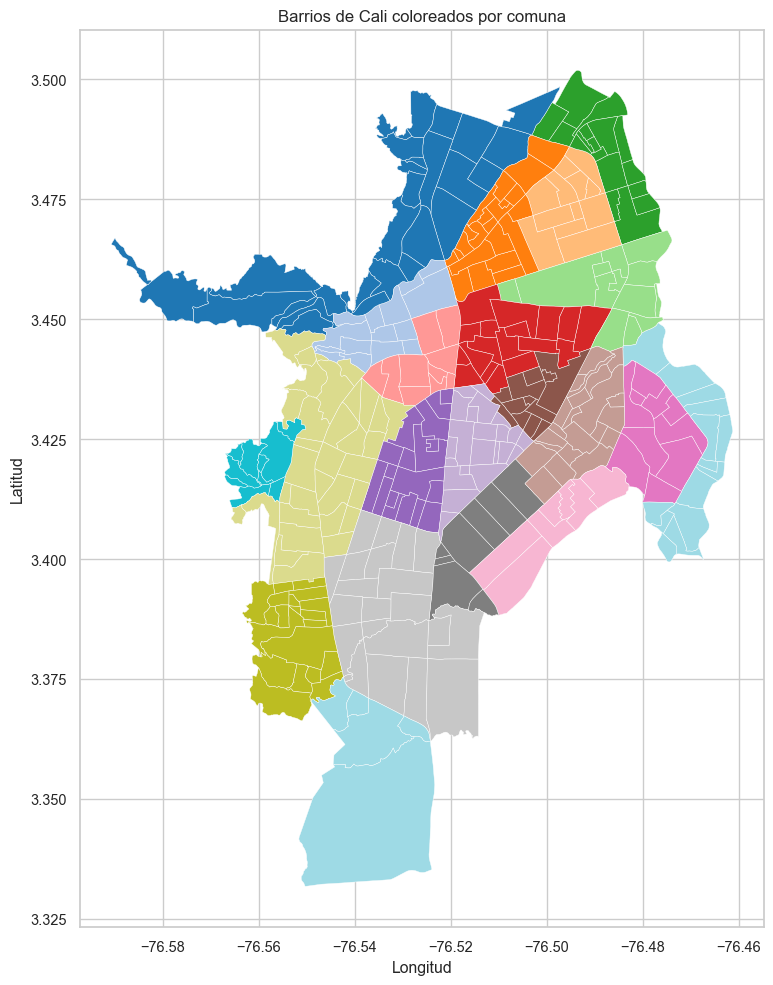

In [9]:
# @title Mapa — todos los barrios (WGS84)
fig, ax = plt.subplots(figsize=(10, 10))
gdf_wgs.plot(ax=ax, column="comuna", cmap="tab20", linewidth=0.3, edgecolor="white", legend=False)
ax.set_title("Barrios de Cali coloreados por comuna", fontsize=12)
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig(OUT_DIR / "03_mapa_barrios_por_comuna.png", dpi=150, bbox_inches="tight")
plt.show()

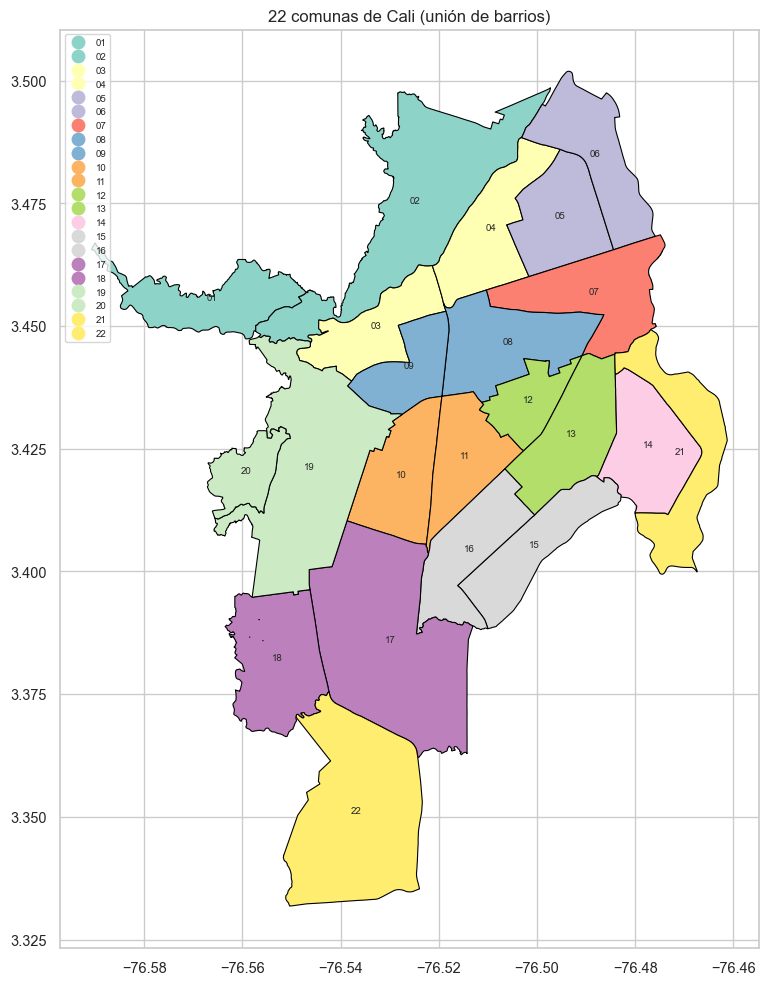

In [10]:
# @title Mapa — comunas agregadas (dissolve)
comunas_gdf = gdf.dissolve(by="comuna", as_index=False)
comunas_wgs = comunas_gdf.to_crs(4326)

fig, ax = plt.subplots(figsize=(10, 10))
comunas_wgs.plot(
    ax=ax, column="comuna", cmap="Set3", linewidth=0.8,
    edgecolor="black", legend=True, legend_kwds={"loc": "upper left", "fontsize": 7},
)
for _, row in comunas_wgs.iterrows():
    c = row.geometry.centroid
    ax.annotate(str(row["comuna"]), (c.x, c.y), fontsize=7, ha="center")
ax.set_title("22 comunas de Cali (unión de barrios)", fontsize=12)
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig(OUT_DIR / "04_mapa_comunas.png", dpi=150, bbox_inches="tight")
plt.show()

comunas_gdf[["comuna", "area_km2"]].groupby("comuna")["area_km2"].sum().to_csv(
    OUT_DIR / "area_comunas_dissolve.csv"
)

KeyError: 'area_km2'

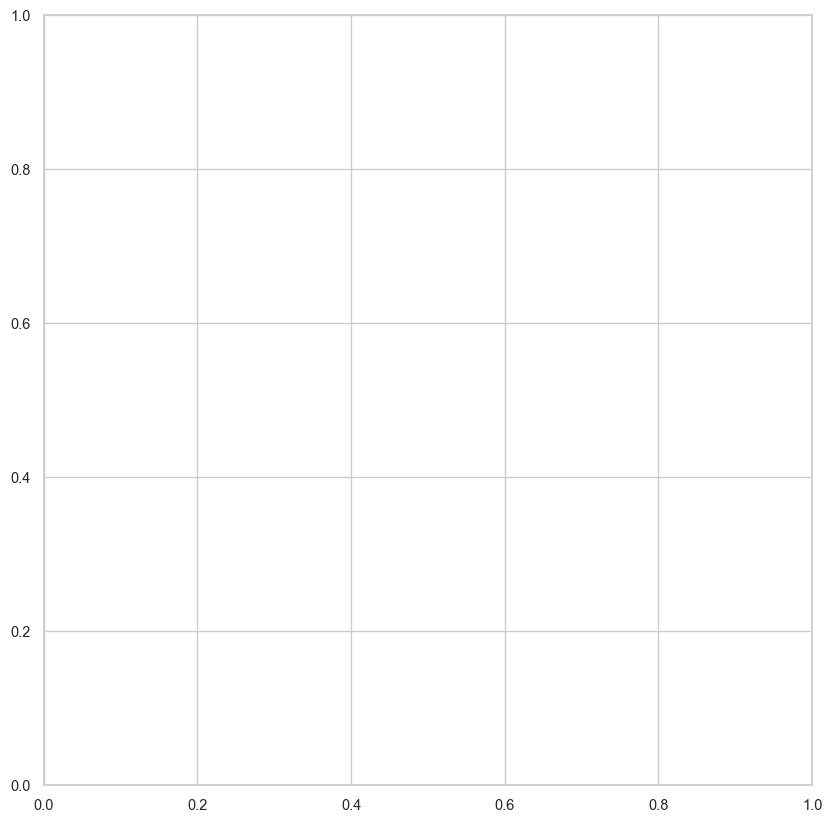

In [11]:
# @title Mapa — área del barrio (choropleth)
fig, ax = plt.subplots(figsize=(10, 10))
gdf_wgs.plot(
    ax=ax, column="area_km2", cmap="YlOrRd", linewidth=0.2,
    edgecolor="gray", legend=True,
    legend_kwds={"label": "Área (km²)", "shrink": 0.6},
)
ax.set_title("Área por barrio (km²)", fontsize=12)
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig(OUT_DIR / "05_mapa_area_barrios.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Calidad de datos y exportación

In [12]:
# @title Chequeos de calidad + catálogo barrios
dup_id = gdf["id_barrio"].duplicated().sum()
dup_nombre = gdf["barrio"].duplicated().sum()
print(f"id_barrio duplicados: {dup_id} (esperado 0)")
print(f"Nombres de barrio duplicados: {dup_nombre} (esperado 0)")

catalogo = gdf.drop(columns="geometry")[[
    "id_barrio", "barrio", "comuna", "area_km2", "perim_km", "shape_area", "shape_leng"
]].sort_values(["comuna", "barrio"], key=lambda c: c.astype(str) if c.name == "comuna" else c)
catalogo.to_csv(OUT_DIR / "catalogo_barrios.csv", index=False)
print(f"Catálogo: {len(catalogo)} filas -> {OUT_DIR / 'catalogo_barrios.csv'}")

resumen = {
    "n_barrios": len(gdf),
    "n_comunas": int(gdf["comuna"].nunique()),
    "crs": str(gdf.crs),
    "area_total_km2": round(float(gdf["area_km2"].sum()), 3),
    "bounds_wgs84": {
        "min_lon": round(float(bounds[0]), 5),
        "min_lat": round(float(bounds[1]), 5),
        "max_lon": round(float(bounds[2]), 5),
        "max_lat": round(float(bounds[3]), 5),
    },
    "comuna_mas_barrios": por_comuna.loc[por_comuna["n_barrios"].idxmax(), "comuna"],
    "comuna_menos_barrios": por_comuna.loc[por_comuna["n_barrios"].idxmin(), "comuna"],
}
(OUT_DIR / "resumen_eda.json").write_text(json.dumps(resumen, indent=2, ensure_ascii=False), encoding="utf-8")
print("\n=== Resumen EDA ===")
for k, v in resumen.items():
    print(f"  {k}: {v}")
print(f"\nArchivos en: {OUT_DIR}")

id_barrio duplicados: 0 (esperado 0)
Nombres de barrio duplicados: 0 (esperado 0)
Catálogo: 339 filas -> c:\Users\nicor\universidad\analitica\proyectos\proyecto 3.1\data\mc_barrios\eda\catalogo_barrios.csv

=== Resumen EDA ===
  n_barrios: 339
  n_comunas: 22
  crs: EPSG:6249
  area_total_km2: 120.024
  bounds_wgs84: {'min_lon': -76.59076, 'min_lat': 3.33182, 'max_lon': -76.46125, 'max_lat': 3.50189}
  comuna_mas_barrios: 19
  comuna_menos_barrios: 01

Archivos en: c:\Users\nicor\universidad\analitica\proyectos\proyecto 3.1\data\mc_barrios\eda
